In [19]:
import os
from astropy.io import fits
from astropy.table import Table
import lsdb
from pathlib import Path
from upath import UPath
from astropy.wcs import WCS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print('Imported libaries.')

Imported libaries.


In [2]:
IMGS_DIR = Path("./kbmod/kbmod_fits_examples/i_band")

In [9]:
def add_white_noise(input_dir, sigma, output_dir):
    """
    Add white Gaussian noise to FITS files (SCIENCE, MASK, VARIANCE HDU structure).

    Parameters
    ----------
    input_dir : str
        Path to directory containing FITS files or subdirectories of FITS files.
    sigma : float
        Standard deviation of the white Gaussian noise.
    output_dir : str
        Path to directory where modified FITS files will be saved, preserving structure.
    """
    for root, dirs, files in os.walk(input_dir):
        # Preserve subdirectory structure in output_dir
        rel_path = os.path.relpath(root, input_dir)
        out_root = os.path.join(output_dir, rel_path)
        os.makedirs(out_root, exist_ok=True)

        for fname in files:
            if not fname.lower().endswith(".fits"):
                continue  # skip non-FITS files

            in_path = os.path.join(root, fname)
            out_path = os.path.join(out_root, fname)

            with fits.open(in_path) as hdul:
                # Copy to new HDU list
                new_hdul = fits.HDUList()
                print(in_path)

                # --- SCIENCE HDU (0) ---
                sci = hdul[1].data.astype(float)
                noise = np.random.normal(0, sigma, size=sci.shape)
                sci_noisy = sci + noise
                new_hdul.append(fits.PrimaryHDU(data=sci_noisy, header=hdul[0].header))

                # --- MASK HDU (1) ---
                new_hdul.append(fits.ImageHDU(data=hdul[1].data, header=hdul[1].header))

                # --- VARIANCE HDU (2) ---
                var = hdul[3].data.astype(float)
                var_updated = var + sigma**2
                new_hdul.append(fits.ImageHDU(data=var_updated, header=hdul[2].header))

                # Write out new FITS file
                new_hdul.writeto(out_path, overwrite=True)


In [10]:
input_dir = IMGS_DIR
sigma = 0.1 # Confer with Kostya to tune accordingly
output_dir = Path(f"./i_band_{sigma}_sig")

In [11]:
add_white_noise(input_dir=input_dir, sigma=sigma, output_dir=output_dir)

kbmod/kbmod_fits_examples/i_band/rings.v3.skycell.2327.023.wrp.i.56793_44472.combined.fits
kbmod/kbmod_fits_examples/i_band/rings.v3.skycell.2327.023.wrp.i.56759_55227.combined.fits
kbmod/kbmod_fits_examples/i_band/rings.v3.skycell.2327.023.wrp.i.55340_33927.combined.fits
kbmod/kbmod_fits_examples/i_band/rings.v3.skycell.2327.023.wrp.i.56404_53091.combined.fits
kbmod/kbmod_fits_examples/i_band/rings.v3.skycell.2327.023.wrp.i.56793_41894.combined.fits
kbmod/kbmod_fits_examples/i_band/rings.v3.skycell.2327.023.wrp.i.55696_43322.combined.fits
kbmod/kbmod_fits_examples/i_band/rings.v3.skycell.2327.023.wrp.i.55339_34326.combined.fits
kbmod/kbmod_fits_examples/i_band/rings.v3.skycell.2327.023.wrp.i.55677_55975.combined.fits
kbmod/kbmod_fits_examples/i_band/rings.v3.skycell.2327.023.wrp.i.56028_54785.combined.fits
kbmod/kbmod_fits_examples/i_band/rings.v3.skycell.2327.023.wrp.i.55677_56475.combined.fits
kbmod/kbmod_fits_examples/i_band/rings.v3.skycell.2327.023.wrp.i.56759_51277.combined.fits

In [ ]:
def plot_science_image(fits_path, vmin=None, vmax=None, cmap="gray"):
    """
    Plot the SCIENCE data (HDU 1) from a FITS file.

    Parameters
    ----------
    fits_path : str
        Path to the FITS file.
    vmin, vmax : float, optional
        Limits for the color scale (for contrast). Defaults to autoscale.
    cmap : str, optional
        Matplotlib colormap. Default is "gray".
    """
    with fits.open(fits_path) as hdul:
        sci_data = hdul[1].data

    plt.figure(figsize=(8, 8))
    plt.imshow(sci_data, origin="lower", cmap='viridis', vmin=vmin, vmax=vmax)
    plt.colorbar(label="Counts")
    plt.title(f"SCIENCE: {fits_path}")
    plt.show()


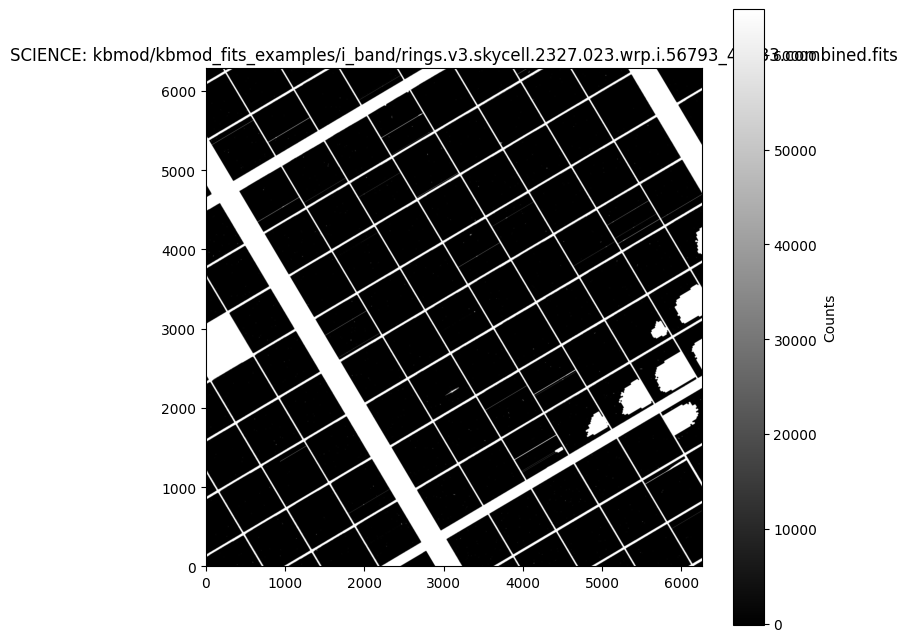

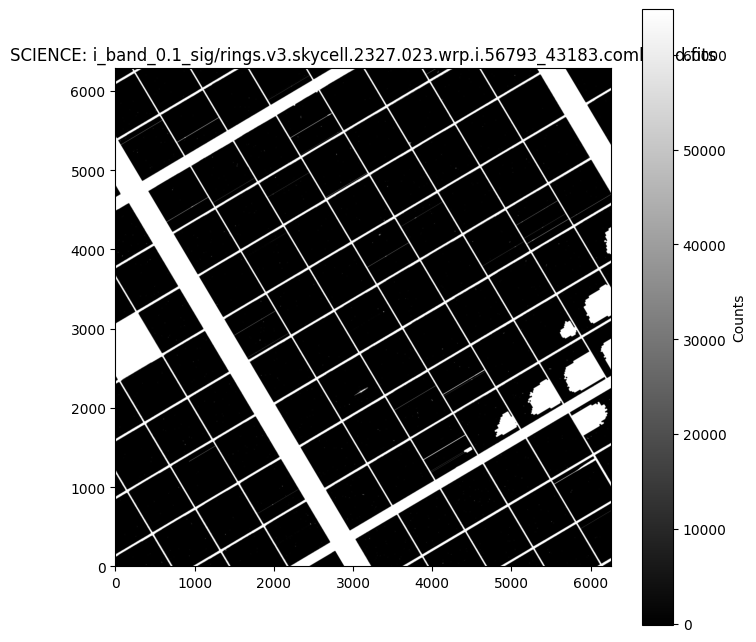

In [ ]:
unchanged_img_path = Path("kbmod/kbmod_fits_examples/i_band/rings.v3.skycell.2327.023.wrp.i.56793_43183.combined.fits")
changed_img_path = Path("./i_band_0.1_sig//rings.v3.skycell.2327.023.wrp.i.56793_43183.combined.fits")

plot_science_image(unchanged_img_path, vmin=0, vmax=20)
plot_science_image(changed_img_path, vmin=0, vmax=20)
